In [44]:
import pandas as pd

tweets_trainset = pd.read_csv('data/TweetsTrainset.txt', sep='\t', header=None)
display(tweets_trainset.head(10))
print(f"Shape: {tweets_trainset.shape}")

,0,1,2
0,1,LOC/Thai Buddhist temple;,"2,000 fetuses found hidden at Thai Buddhist te..."
1,2,LOC/canada;,"870, 000 people in canada depend on #FakeHasht..."
2,3,PER/louis;,"7961212234, phone this girl! she is like louis..."
3,4,ORG/WikiLeaks;LOC/Southern Ocean;,@FakeUsername : WikiLeaks Set To Reveal US-UFO...
4,5,ORG/queen;,"@FakeUsername queen, bohemian rhapsody please"
5,6,PER/cheryl cole;PER/Danni;PER/eddie;,cheryl cole is starting to lose that connectio...
6,7,ORG/Lester;MISC/Mason & Begg Limited;,"Lester, '' Mason & Begg Limited : '' '' `Forbi..."
7,8,PER/Thomas Watson;,"To be successful, you have to have your heart ..."
8,9,"PER/Sanchez;PER/Eli Wallach;MISC/The Good, The...","Sanchez looks like Eli Wallach in The Good, Th..."
9,10,NaN,"@FakeUsername the history of the mayor, the ci..."


Shape: (2815, 3)


In [45]:
import re
import pandas as pd
from collections import Counter
import nltk

# BIO Tagging Alignment
print("BIO Tagging Alignment\n" + "="*70)

# Helper function: Find entity positions in text
def find_entities(text, entities_dict):
    """Find character positions of all entities in text"""
    entity_spans = {}
    for ent_type, names in entities_dict.items():
        entity_spans[ent_type] = []
        for name in names:
            pattern = re.compile(re.escape(name), re.IGNORECASE)
            for match in pattern.finditer(text):
                entity_spans[ent_type].append((match.start(), match.end()))
    return entity_spans

# Helper function: Parse entity string
def parse_entities(ent_str):
    """Parse 'TYPE/entity; ' format"""
    entities = {}
    if pd.isna(ent_str) or not str(ent_str).strip():
        return entities
    
    for pair in str(ent_str).split(';'):
        if '/' in pair:
            ent_type, name = pair.split('/', 1)
            ent_type = ent_type.strip()
            name = name.strip()
            if ent_type not in entities:
                entities[ent_type] = []
            entities[ent_type].append(name)
    return entities

# Helper function: Assign BIO tags
def get_bio_tags(tokens, positions, entity_spans):
    """Assign BIO tags to tokens based on entity positions"""
    tags = []
    for start, end, token in positions:
        tag = 'O'
        
        for ent_type, spans in entity_spans.items():
            for ent_start, ent_end in spans:
                if start >= ent_start and end <= ent_end:
                    tag = 'B-' + ent_type if start == ent_start else 'I-' + ent_type
                    break
            if tag != 'O':
                break
        tags.append(tag)
    return tags

# Process all sequences
pattern = r"(https?://\S+|@\w+|#\w+|[\w']+|[^\w\s])"

sequences = []
for idx, row in tweets_trainset.iterrows():
    text = row[2]
    
    # Get NLTK tokens with positions
    tokens_pos = []
    for match in re.finditer(pattern, text):
        token = match.group()
        start = match.start()
        end = match.end()
        tokens_pos.append((start, end, token))
    
    # Parse and find entities
    entities = parse_entities(row[1])
    entity_spans = find_entities(text, entities)
    
    # Get tokens and tags
    tokens = [t for _, _, t in tokens_pos]
    tags = get_bio_tags(tokens, tokens_pos, entity_spans)
    
    if tokens:
        sequences.append({
            'text': text,
            'tokens': tokens,
            'tags': tags,
            'num_tokens': len(tokens)
        })


sequences_df = pd.DataFrame(sequences)

print(f"\nTotal sequences: {len(sequences_df):,}")

# Sample sequences
print("\n" + "-"*70)
print("SAMPLE SEQUENCES:\n")
for i in range(min(3, len(sequences_df))):
    s = sequences_df.iloc[i]
    print(f"Sequence {i+1}:")
    print(f"  Text:   {s['text']}")
    print(f"  Tokens: {s['tokens']}")
    print(f"  Tags:   {s['tags']}")
    print()

display(sequences_df.head(10))


BIO Tagging Alignment

Total sequences: 2,815

----------------------------------------------------------------------
SAMPLE SEQUENCES:

Sequence 1:
  Text:   2,000 fetuses found hidden at Thai Buddhist temple http://FakeURL via @FakeUsername
  Tokens: ['2', ',', '000', 'fetuses', 'found', 'hidden', 'at', 'Thai', 'Buddhist', 'temple', 'http://FakeURL', 'via', '@FakeUsername']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O']

Sequence 2:
  Text:   870, 000 people in canada depend on #FakeHashtag -25% increase in the last 2 years - please give generously
  Tokens: ['870', ',', '000', 'people', 'in', 'canada', 'depend', 'on', '#FakeHashtag', '-', '25', '%', 'increase', 'in', 'the', 'last', '2', 'years', '-', 'please', 'give', 'generously']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Sequence 3:
  Text:   7961212234, phone this girl! she is like louis biggest fan! < 3 @F

,text,tokens,tags,num_tokens
0,"2,000 fetuses found hidden at Thai Buddhist te...","[2, ,, 000, fetuses, found, hidden, at, Thai, ...","[O, O, O, O, O, O, O, B-LOC, I-LOC, I-LOC, O, ...",13
1,"870, 000 people in canada depend on #FakeHasht...","[870, ,, 000, people, in, canada, depend, on, ...","[O, O, O, O, O, B-LOC, O, O, O, O, O, O, O, O,...",22
2,"7961212234, phone this girl! she is like louis...","[7961212234, ,, phone, this, girl, !, she, is,...","[O, O, O, O, O, O, O, O, O, B-PER, O, O, O, O,...",19
3,@FakeUsername : WikiLeaks Set To Reveal US-UFO...,"[@FakeUsername, :, WikiLeaks, Set, To, Reveal,...","[O, O, B-ORG, O, O, O, O, O, O, O, O, B-LOC, I...",26
4,"@FakeUsername queen, bohemian rhapsody please","[@FakeUsername, queen, ,, bohemian, rhapsody, ...","[O, B-ORG, O, O, O, O]",6
5,cheryl cole is starting to lose that connectio...,"[cheryl, cole, is, starting, to, lose, that, c...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, B...",28
6,"Lester, '' Mason & Begg Limited : '' '' `Forbi...","[Lester, ,, '', Mason, &, Begg, Limited, :, ''...","[B-ORG, O, O, B-MISC, I-MISC, I-MISC, I-MISC, ...",30
7,"To be successful, you have to have your heart ...","[To, be, successful, ,, you, have, to, have, y...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",26
8,"Sanchez looks like Eli Wallach in The Good, Th...","[Sanchez, looks, like, Eli, Wallach, in, The, ...","[B-PER, O, O, B-PER, I-PER, O, B-MISC, I-MISC,...",19
9,"@FakeUsername the history of the mayor, the ci...","[@FakeUsername, the, history, of, the, mayor, ...","[O, O, O, O, O, O, O, O, O, O]",10


In [46]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# K-Fold Cross-Validation Setup
print("K-Fold Cross-Validation Setup\n" + "="*70)

K_FOLDS = 5
RANDOM_STATE = 42

# Create stratification labels (to balance entity distribution across folds)
stratification_labels = []
for tags in sequences_df['tags']:
    entity_tags = [t for t in tags if t != 'O']
    if len(entity_tags) > 0:
        stratification_labels.append(1) 
    else:
        stratification_labels.append(0) 

# Create K-Fold splitter
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(skf.split(sequences_df, stratification_labels))

print(f"Total sequences: {len(sequences_df):,}")
print(f"Number of folds: {K_FOLDS}")
print(f"\nFold sizes:")
for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"  Fold {fold_idx + 1}: Train={len(train_idx):,} | Validation={len(val_idx):,}")

# Helper function: Convert DataFrame to NER format
def df_to_ner_format(df):
    """Convert DataFrame to list of (tokens, tags) for NER training"""
    return [(row['tokens'], row['tags']) for _, row in df.iterrows()]

# Initialize tracking dictionaries for all model variants
fold_scores_A1 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_A2 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_B = {'precision': [], 'recall': [], 'f1': []}
fold_scores_C1 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_C2 = {'precision': [], 'recall': [], 'f1': []}
best_models_per_fold = {'A1': [], 'A2': [], 'B': [], 'C1': [], 'C2': []}

print("\n K-Fold setup complete. Ready for model training.")

K-Fold Cross-Validation Setup
Total sequences: 2,815
Number of folds: 5

Fold sizes:
  Fold 1: Train=2,252 | Validation=563
  Fold 2: Train=2,252 | Validation=563
  Fold 3: Train=2,252 | Validation=563
  Fold 4: Train=2,252 | Validation=563
  Fold 5: Train=2,252 | Validation=563

 K-Fold setup complete. Ready for model training.


In [47]:
try:
    from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
except ImportError:
    print("seqeval not found.")
    %pip install seqeval

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not found.")
    %pip install matplotlib

# Evaluation function
def evaluate_ner(y_true, y_pred, set_name="Validation"):
    """
    Evaluate NER using seqeval (works directly with BIO tags!)
    
    Args:
        y_true: List of tag sequences [['B-PER', 'I-PER', 'O']]
        y_pred: List of predicted tag sequences
    """
    print(f"\nEvaluation Results for {set_name} Set\n" + "-"*70)

    # Calculate metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Precision (Micro): {precision:.4f}")
    print(f"Recall (Micro):    {recall:.4f}")
    print(f"F1-Score (Micro):  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {'precision': precision, 'recall': recall, 'f1': f1}

def plot_confusion_matrix(y_true, y_pred, set_name="Validation"):
    """Plot confusion matrix for BIO tags"""
    # Flatten lists
    y_true_flat = [tag for seq in y_true for tag in seq]
    y_pred_flat = [tag for seq in y_pred for tag in seq]

    all_tags = sorted(set(y_true_flat + y_pred_flat))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=all_tags)

    fig, ax = plt.subplots(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_tags)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {set_name} Set")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Evaluation Framework Finished\n")

Evaluation Framework Finished



METHOD A: Rule-Based + CRF Approach

In [48]:
print("METHOD A - Rule-Based + CRF Approach\n" + "="*70)

import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

def get_mapped_word(word):
    w_lower = word.lower()
    if word.startswith('@'):
        return '_MENTION_'
    if word.startswith('http') or word.startswith('www'):
        return '_URL_'
    if word.startswith('#'):
        return '_HASHTAG_'
    return w_lower

def word2features_A1(word, pos):
    """ Extract 11 basic features for a word.

    word: The word token
    pos: Part-of-speech tag of the word

    Returns a dictionary of features for sklearn-crfsuite.
    """

    word_mapped = get_mapped_word(word)
        
    features_A1 = {
        'bias': 1.0,
        'len(word)': len(word), # Length of the word
        'word.lower()': word_mapped, # Lowercase form of the word
        'word[-3:]': word[-3:], # Last 3 characters (suffix)
        'word[-2:]': word[-2:], # Last 2 characters (suffix)
        'word[:3]': word[:3], # First 3 characters (prefix)
        'word[:2]': word[:2], # First 2 characters (prefix)
        'word.isupper()': word.isupper(),
        'word.islower()': word.islower(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': pos,
        'word.shape': ''.join(['X' if c.isupper() else 'x' for c in word if c.isalpha()]), # Shape feature (e.g., 'Xx' for 'John', 'xxx' for 'cat')
        'is_mention': word.startswith('@'),
        'is_hashtag': word.startswith('#'),
    }
    return features_A1

def sent2features_A1(sent):
    """
    Extract features for all words in a sentence.
    POS tag the entire sentence at once for efficiency.

    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """

    # POS tag entire sentence at once
    pos_tags = pos_tag(sent) # Returns [(word, tag), (word, tag)]
    # Extract features for each word with its POS tag
    return [word2features_A1(word, pos) for word, pos in pos_tags]

print("A1 feature functions defined")

METHOD A - Rule-Based + CRF Approach
A1 feature functions defined


In [49]:
print("Feature Extraction - VARIATION A2: Contextual Features\n" + "="*70)

def word2features_A2(sent, i, pos_tags):
    """
    Extract contextual features for word at position i.
    Includes: current word features + previous and next word features + BOS/EOS.

    sent: List of tokens in the sentence
    i: Index of target word
    pos_tags: List of (word, POS) tuples from pos_tag(sent)

    Return: Dictionary of features for the word at position i
    """
    
    word = sent[i]
    pos = pos_tags[i][1]  # POS tag for current word
    word_mapped = get_mapped_word(word)

    features_A2 = {
        'bias': 1.0,
        'len(word)': len(word),
        'word.lower()': word_mapped,
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],
        'word[:2]': word[:2],
        'word.isupper()': word.isupper(),
        'word.islower()': word.islower(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': pos,
        'word.shape': ''.join(['X' if c.isupper() else 'x' for c in word if c.isalpha()]),
        'is_mention': word.startswith('@'),
        'is_hashtag': word.startswith('#'),
    }

    # Previous word features
    if i > 0:
        prev_word = sent[i-1]
        prev_pos = pos_tags[i-1][1]
        features_A2.update({
            'prev_word.istitle()': prev_word.istitle(),
            'prev_word.isupper()': prev_word.isupper(),
            'prev_word.isdigit()': prev_word.isdigit(),
            'prev_word.islower()': prev_word.islower(),
            'word_bigram_prev': prev_word.lower() + "+" + word.lower(),
            'pos_bigram_prev': prev_pos + "+" + pos,
            'prev_postag': prev_pos,
        })
    else:
        features_A2['BOS'] = True  # Beginning of sentence
        features_A2['prev_word.lower()'] = 'BOS'
        features_A2['prev_postag'] = 'BOS'
    
    # Next word features
    if i < len(sent) - 1:
        next_word = sent[i+1]
        next_pos = pos_tags[i+1][1]
        features_A2.update({
            'next_word.istitle()': next_word.istitle(),
            'next_word.isupper()': next_word.isupper(),
            'next_word.isdigit()': next_word.isdigit(),
            'next_word.islower()': next_word.islower(),
            'word_bigram_next': word.lower() + "+" + next_word.lower(),
            'next_postag': next_pos,
            'pos_bigram_next': pos + "+" + next_pos,
        })
    else:
        features_A2['EOS'] = True  # End of sentence
        features_A2['next_word.lower()'] = 'EOS'
        features_A2['next_postag'] = 'EOS'

    return features_A2

def sent2features_A2(sent):
    """
    Extract features for all words in a sentence using contextual features.
    
    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """
    pos_tags = pos_tag(sent)
    return [word2features_A2(sent, i, pos_tags) for i in range(len(sent))]

print("A2 feature functions defined")

Feature Extraction - VARIATION A2: Contextual Features
A2 feature functions defined


In [ ]:
import json

sample_idx =  0
sample_tokens = sequences_df.iloc[sample_idx]['tokens']


sample_features_A1 = sent2features_A1(sample_tokens)
sample_features_A2 = sent2features_A2(sample_tokens)

print(f"Text: {' '.join(sample_tokens)}")
print(f"Tags: {sequences_df.iloc[sample_idx]['tags']}")

for word_idx in range(len(sample_tokens)):
    print("="*50)
    print(f"TOKEN: '{sample_tokens[word_idx]}' --> Tag: {sequences_df.iloc[sample_idx]['tags'][word_idx]}")
 
    print("\n[VARIATION A1] - Basic Features:")
    print(sample_features_A1[word_idx])
 
    print("\n[VARIATION A2] - Contextual:")
    print(sample_features_A2[word_idx])

Text: 2 , 000 fetuses found hidden at Thai Buddhist temple http://FakeURL via @FakeUsername
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O']
TOKEN: '2' --> Tag: O

[VARIATION A1] - Basic Features:
{'bias': 1.0, 'len(word)': 1, 'word.lower()': '2', 'word[-3:]': '2', 'word[-2:]': '2', 'word[:3]': '2', 'word[:2]': '2', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': True, 'postag': 'CD', 'word.shape': '', 'is_mention': False, 'is_hashtag': False}

[VARIATION A2] - Contextual:
{'bias': 1.0, 'len(word)': 1, 'word.lower()': '2', 'word[-3:]': '2', 'word[-2:]': '2', 'word[:3]': '2', 'word[:2]': '2', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': True, 'postag': 'CD', 'word.shape': '', 'is_mention': False, 'is_hashtag': False, 'BOS': True, 'prev_word.lower()': 'BOS', 'prev_postag': 'BOS', 'next_word.istitle()': False, 'next_word.isupper()': False, 'next_word.isdigit()': 

In [51]:
print("FEATURE EXTRACTION FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

# Dictionary to store all features per fold
all_fold_features = {}

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS}")
    print(f"{'='*70}")
    
    # Get train/val data for this fold
    train_df = sequences_df.iloc[train_idx].reset_index(drop=True)
    val_df = sequences_df.iloc[val_idx].reset_index(drop=True)
    
    print(f"Train sequences: {len(train_df):,} | Val sequences: {len(val_df):,}")
    
    # Convert to NER format (list of (tokens, tags))
    train_data = df_to_ner_format(train_df)
    val_data = df_to_ner_format(val_df)
    
    # METHOD A: A1 & A2 FEATURES
    
    # Extract A1 features (basic)
    print(f"  Extracting A1 features (basic)")
    X_train_A1 = [sent2features_A1(tokens) for tokens, tags in train_data]
    y_train_A1 = [tags for tokens, tags in train_data]
    
    X_val_A1 = [sent2features_A1(tokens) for tokens, tags in val_data]
    y_val_A1 = [tags for tokens, tags in val_data]
    print(f"    ✓ A1 train: {len(X_train_A1)} | val: {len(X_val_A1)}")
    
    # Extract A2 features (contextual)
    print(f"  Extracting A2 features (contextual)")
    X_train_A2 = [sent2features_A2(tokens) for tokens, tags in train_data]
    y_train_A2 = [tags for tokens, tags in train_data]
    
    X_val_A2 = [sent2features_A2(tokens) for tokens, tags in val_data]
    y_val_A2 = [tags for tokens, tags in val_data]
    print(f"    ✓ A2 train: {len(X_train_A2)} | val: {len(X_val_A2)}")
    
    # Store all features for this fold
    all_fold_features[fold_idx] = {
        'X_train_A1': X_train_A1, 'y_train_A1': y_train_A1,
        'X_val_A1': X_val_A1, 'y_val_A1': y_val_A1,
        'X_train_A2': X_train_A2, 'y_train_A2': y_train_A2,
        'X_val_A2': X_val_A2, 'y_val_A2': y_val_A2,
    }

print(f"\n{'='*70}")
print(f"Feature extraction complete for all {K_FOLDS} folds (METHOD A - A1 & A2).")
print(f"{'='*70}\n")

FEATURE EXTRACTION FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    ✓ A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    ✓ A2 train: 2252 | val: 563

FOLD 2 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    ✓ A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    ✓ A2 train: 2252 | val: 563

FOLD 3 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    ✓ A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    ✓ A2 train: 2252 | val: 563

FOLD 4 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    ✓ A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    ✓ A2 train: 2252 | val: 563

FOLD 5 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    ✓ A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    ✓ A2 train: 2252 | val: 563

In [52]:
from sklearn_crfsuite import CRF
from sklearn.model_selection import RandomizedSearchCV
import time

print("TRAIN CRF MODELS FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

# Dictionary to store predictions for evaluation
all_fold_predictions = {}

# CRF hyperparameter search space
params_space = {
    'c1': np.logspace(-3, 3, 7),  # L1 regularization
    'c2': np.logspace(-3, 3, 7),  # L2 regularization
}

for fold_idx in range(K_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS} - TRAINING")
    print(f"{'='*70}")
    
    # Retrieve features from storage
    features = all_fold_features[fold_idx]
    X_train_A1 = features['X_train_A1']
    y_train_A1 = features['y_train_A1']
    X_val_A1 = features['X_val_A1']
    y_val_A1 = features['y_val_A1']
    
    X_train_A2 = features['X_train_A2']
    y_train_A2 = features['y_train_A2']
    X_val_A2 = features['X_val_A2']
    y_val_A2 = features['y_val_A2']
    
    # TRAIN A1 (BASIC FEATURES)
    print(f"\n  Training A1 (basic features)")
    start_time_A1 = time.time()
    
    # Base CRF model
    crf_A1 = CRF(
        algorithm='lbfgs',
        max_iterations=100,
        all_possible_transitions=True,
        verbose=False
    )
    
    # RandomizedSearchCV for hyperparameter tuning
    rs_A1 = RandomizedSearchCV(
        crf_A1,
        params_space,
        cv=3,
        n_iter=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    
    # Train
    rs_A1.fit(X_train_A1, y_train_A1)
    train_time_A1 = time.time() - start_time_A1
    
    print(f"    Best params A1: c1={rs_A1.best_params_['c1']:.6f}, c2={rs_A1.best_params_['c2']:.6f}")
    print(f"    Best CV score: {rs_A1.best_score_:.4f}")
    print(f"    Training time: {train_time_A1:.2f}s")
    
    # Make predictions
    y_pred_A1_val = rs_A1.predict(X_val_A1)
    
    # Store best model
    best_models_per_fold['A1'].append(rs_A1.best_estimator_)
    
    # TRAIN A2 (CONTEXTUAL FEATURES)
    print(f"\n  Training A2 (contextual features)")
    start_time_A2 = time.time()
    
    # Base CRF model
    crf_A2 = CRF(
        algorithm='lbfgs',
        max_iterations=100,
        all_possible_transitions=True,
        verbose=False
    )
    
    # RandomizedSearchCV for hyperparameter tuning
    rs_A2 = RandomizedSearchCV(
        crf_A2,
        params_space,
        cv=3,
        n_iter=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    
    # Train
    rs_A2.fit(X_train_A2, y_train_A2)
    train_time_A2 = time.time() - start_time_A2
    
    print(f"    Best params A2: c1={rs_A2.best_params_['c1']:.6f}, c2={rs_A2.best_params_['c2']:.6f}")
    print(f"    Best CV score: {rs_A2.best_score_:.4f}")
    print(f"    Training time: {train_time_A2:.2f}s")
    
    # Make predictions
    y_pred_A2_val = rs_A2.predict(X_val_A2)
    
    # Store best model
    best_models_per_fold['A2'].append(rs_A2.best_estimator_)
    
    #STORE PREDICTIONS FOR EVALUATION
    all_fold_predictions[fold_idx] = {
        'y_val_A1': y_val_A1, 'y_pred_A1': y_pred_A1_val,
        'y_val_A2': y_val_A2, 'y_pred_A2': y_pred_A2_val,
    }

print(f"\n{'='*70}")
print(f"Training complete for all {K_FOLDS} folds")
print(f"{'='*70}\n")

TRAIN CRF MODELS FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.100000, c2=1.000000
    Best CV score: 0.9337
    Training time: 13.51s

  Training A2 (contextual features)
    Best params A2: c1=0.100000, c2=1.000000
    Best CV score: 0.9383
    Training time: 20.42s

FOLD 2 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.100000, c2=1.000000
    Best CV score: 0.9338
    Training time: 10.46s

  Training A2 (contextual features)
    Best params A2: c1=0.100000, c2=1.000000
    Best CV score: 0.9395
    Training time: 20.75s

FOLD 3 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.100000, c2=1.000000
    Best CV score: 0.9317
    Training time: 10.30s

  Training A2 (contextual features)
    Best params A2: c1=0.100000, c2=1.000000
    Best CV score: 0.9366
    Training time: 20.77s

FOLD 4 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.100000, c2=1.00000

In [53]:
print("EVALUATE CRF MODELS FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

for fold_idx in range(K_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS} - EVALUATION")
    print(f"{'='*70}")
    
    # Retrieve predictions
    predictions = all_fold_predictions[fold_idx]
    y_val_A1 = predictions['y_val_A1']
    y_pred_A1 = predictions['y_pred_A1']
    y_val_A2 = predictions['y_val_A2']
    y_pred_A2 = predictions['y_pred_A2']
    
    # EVALUATE A1 
    print(f"\n  Evaluating A1 (basic features)")
    metrics_A1 = evaluate_ner(y_val_A1, y_pred_A1, set_name=f"Fold {fold_idx + 1} - A1")
    
    # Store metrics for this fold
    fold_scores_A1['precision'].append(metrics_A1['precision'])
    fold_scores_A1['recall'].append(metrics_A1['recall'])
    fold_scores_A1['f1'].append(metrics_A1['f1'])
    
    # EVALUATE A2
    print(f"\n  Evaluating A2 (contextual features)")
    metrics_A2 = evaluate_ner(y_val_A2, y_pred_A2, set_name=f"Fold {fold_idx + 1} - A2")
    
    # Store metrics for this fold
    fold_scores_A2['precision'].append(metrics_A2['precision'])
    fold_scores_A2['recall'].append(metrics_A2['recall'])
    fold_scores_A2['f1'].append(metrics_A2['f1'])
    
    # FOLD SUMMARY
    print(f"\n  Fold {fold_idx + 1} Summary:")
    print(f"    A1 F1: {metrics_A1['f1']:.4f} | A2 F1: {metrics_A2['f1']:.4f}")
    f1_diff = metrics_A2['f1'] - metrics_A1['f1']
    if f1_diff > 0:
        print(f"    --> A2 better by {f1_diff:.4f}")
    else:
        print(f"    --> A1 better by {abs(f1_diff):.4f}")

print(f"\n{'='*70}")
print(f"Evaluation complete for all {K_FOLDS} folds")
print(f"{'='*70}\n")

EVALUATE CRF MODELS FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5 - EVALUATION

  Evaluating A1 (basic features)

Evaluation Results for Fold 1 - A1 Set
----------------------------------------------------------------------
Precision (Micro): 0.7180
Recall (Micro):    0.5050
F1-Score (Micro):  0.5930

Classification Report:
              precision    recall  f1-score   support

         LOC       0.81      0.37      0.51       117
        MISC       0.60      0.15      0.24        41
         ORG       0.80      0.42      0.55       111
         Org       0.00      0.00      0.00         1
         PER       0.69      0.63      0.66       330

   micro avg       0.72      0.51      0.59       600
   macro avg       0.58      0.31      0.39       600
weighted avg       0.73      0.51      0.58       600


  Evaluating A2 (contextual features)

Evaluation Results for Fold 1 - A2 Set
----------------------------------------------------------------------
Precision (Micro): 0.7581
Recall (Micro): 

/opt/anaconda3/envs/topic5project/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         LOC       0.75      0.46      0.57       114
        MISC       0.50      0.09      0.15        55
         ORG       0.79      0.36      0.50       139
         PER       0.73      0.63      0.68       341

   micro avg       0.74      0.50      0.59       649
   macro avg       0.69      0.39      0.47       649
weighted avg       0.73      0.50      0.58       649


  Fold 2 Summary:
    A1 F1: 0.5543 | A2 F1: 0.5943
    --> A2 better by 0.0400

FOLD 3 / 5 - EVALUATION

  Evaluating A1 (basic features)

Evaluation Results for Fold 3 - A1 Set
----------------------------------------------------------------------
Precision (Micro): 0.8010
Recall (Micro):    0.5111
F1-Score (Micro):  0.6240

Classification Report:
              precision    recall  f1-score   support

         LOC       0.80      0.37      0.50       120
        MISC       0.69      0.18      0.29        49
         ORG       0.76      0.35      0.48      

AGGREGATE RESULTS & SELECT BEST METHOD A

FOLD-BY-FOLD RESULTS

  Fold  A1 F1  A2 F1   Diff Winner
    1 0.5930 0.6330 0.0401     A2
    2 0.5543 0.5943 0.0400     A2
    3 0.6240 0.6616 0.0376     A2
    4 0.6106 0.6522 0.0415     A2
    5 0.6066 0.6272 0.0206     A2

AVERAGE METRICS ACROSS 5 FOLDS


,Model,Precision,Recall,F1-Score
0,A1 (Basic),0.7501,0.4970,0.5977 ± 0.0239
1,A2 (Contextual),0.7753,0.5360,0.6337 ± 0.0233



DECISION: SELECT BEST METHOD A

F1 Difference (A2 - A1): 0.035959
Threshold: 0.01

SELECTED: A2 (Mean F1: 0.6337)
  Reason: A2 better by 0.035959 > threshold 0.01

PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)



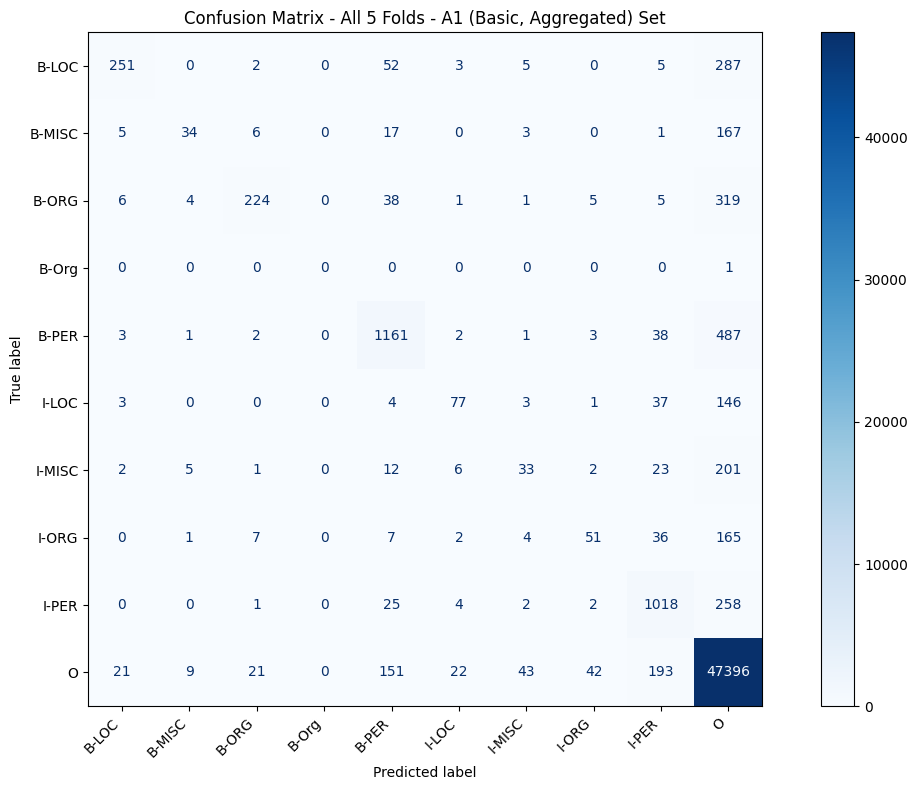

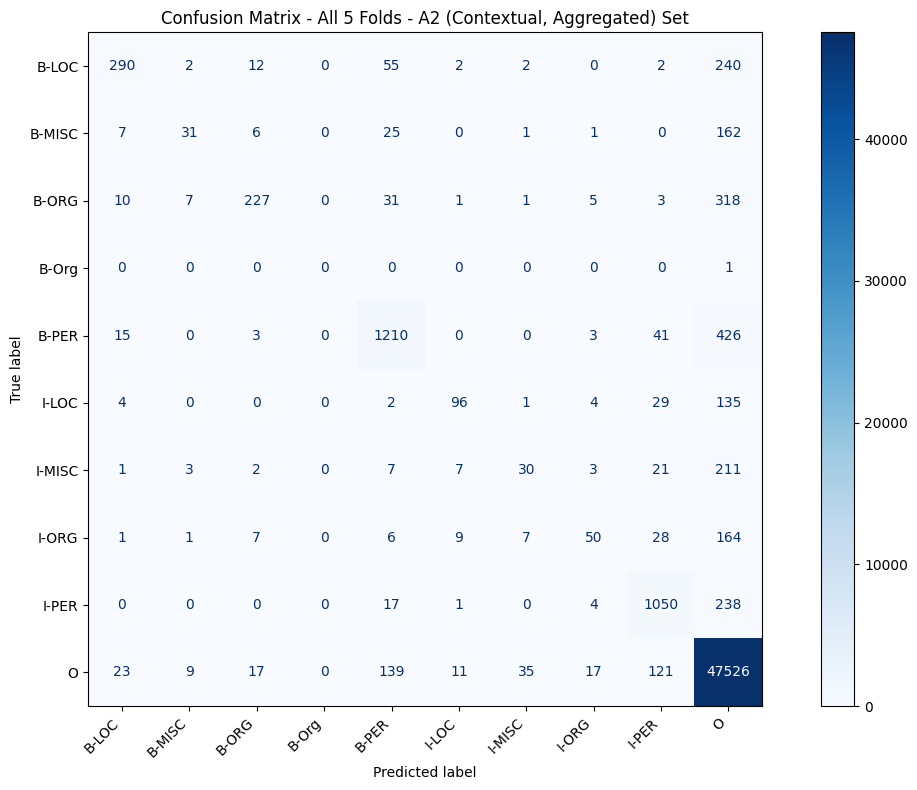


METHOD A COMPLETE: A2 selected as representative model



In [54]:
print("AGGREGATE RESULTS & SELECT BEST METHOD A\n" + "="*70)

# Calculate mean metrics for A1
mean_precision_A1 = np.mean(fold_scores_A1['precision'])
mean_recall_A1 = np.mean(fold_scores_A1['recall'])
mean_f1_A1 = np.mean(fold_scores_A1['f1'])
std_f1_A1 = np.std(fold_scores_A1['f1'])

# Calculate mean metrics for A2
mean_precision_A2 = np.mean(fold_scores_A2['precision'])
mean_recall_A2 = np.mean(fold_scores_A2['recall'])
mean_f1_A2 = np.mean(fold_scores_A2['f1'])
std_f1_A2 = np.std(fold_scores_A2['f1'])

# Compare A1 vs A2
f1_diff = mean_f1_A2 - mean_f1_A1
f1_threshold = 0.01

print("\n" + "="*70)
print("FOLD-BY-FOLD RESULTS")
print("="*70)

# Display per-fold results
results_data = []
for fold_idx in range(K_FOLDS):
    results_data.append({
        'Fold': fold_idx + 1,
        'A1 F1': f"{fold_scores_A1['f1'][fold_idx]:.4f}",
        'A2 F1': f"{fold_scores_A2['f1'][fold_idx]:.4f}",
        'Diff': f"{fold_scores_A2['f1'][fold_idx] - fold_scores_A1['f1'][fold_idx]:.4f}",
        'Winner': 'A2' if fold_scores_A2['f1'][fold_idx] > fold_scores_A1['f1'][fold_idx] else 'A1'
    })

results_df = pd.DataFrame(results_data)
print("\n", results_df.to_string(index=False))

print("\n" + "="*70)
print("AVERAGE METRICS ACROSS 5 FOLDS")
print("="*70)

# Create summary table
summary_data = {
    'Model': ['A1 (Basic)', 'A2 (Contextual)'],
    'Precision': [f"{mean_precision_A1:.4f}", f"{mean_precision_A2:.4f}"],
    'Recall': [f"{mean_recall_A1:.4f}", f"{mean_recall_A2:.4f}"],
    'F1-Score': [f"{mean_f1_A1:.4f} ± {std_f1_A1:.4f}", f"{mean_f1_A2:.4f} ± {std_f1_A2:.4f}"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Decision logic
print("\n" + "="*70)
print("DECISION: SELECT BEST METHOD A")
print("="*70)

print(f"\nF1 Difference (A2 - A1): {f1_diff:.6f}")
print(f"Threshold: {f1_threshold}")

if abs(f1_diff) <= f1_threshold:
    best_A = 'A1'
    reason = f"Difference {abs(f1_diff):.6f} ≤ threshold {f1_threshold} → Choose simpler model (A1)"
else:
    if f1_diff > 0:
        best_A = 'A2'
        reason = f"A2 better by {f1_diff:.6f} > threshold {f1_threshold}"
    else:
        best_A = 'A1'
        reason = f"A1 better by {abs(f1_diff):.6f} > threshold {f1_threshold}"

print(f"\nSELECTED: {best_A} (Mean F1: {max(mean_f1_A1, mean_f1_A2):.4f})")
print(f"  Reason: {reason}")

# PLOT CONFUSION MATRICES (AGGREGATED - ALL 5 FOLDS)
print(f"\n{'='*70}")
print("PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)")
print(f"{'='*70}\n")

# Concatenate predictions from all 5 folds
y_val_A1_all = []
y_pred_A1_all = []
y_val_A2_all = []
y_pred_A2_all = []

for fold_idx in range(K_FOLDS):
    fold_predictions = all_fold_predictions[fold_idx]
    y_val_A1_all.extend(fold_predictions['y_val_A1'])
    y_pred_A1_all.extend(fold_predictions['y_pred_A1'])
    y_val_A2_all.extend(fold_predictions['y_val_A2'])
    y_pred_A2_all.extend(fold_predictions['y_pred_A2'])

# Plot confusion matrix for A1 (aggregated)
plot_confusion_matrix(y_val_A1_all, y_pred_A1_all, set_name="All 5 Folds - A1 (Basic, Aggregated)")

# Plot confusion matrix for A2 (aggregated)
plot_confusion_matrix(y_val_A2_all, y_pred_A2_all, set_name="All 5 Folds - A2 (Contextual, Aggregated)")

# Store best Model A for later comparison with Method B & C
best_method_A = best_A
best_scores_A = {
    'precision': mean_precision_A2 if best_A == 'A2' else mean_precision_A1,
    'recall': mean_recall_A2 if best_A == 'A2' else mean_recall_A1,
    'f1': mean_f1_A2 if best_A == 'A2' else mean_f1_A1,
    'std_f1': std_f1_A2 if best_A == 'A2' else std_f1_A1
}

print(f"\n{'='*70}")
print(f"METHOD A COMPLETE: {best_A} selected as representative model")
print(f"{'='*70}\n")